  0%|          | 0/1557 [00:00<?, ?it/s]

Total mask pixels: 32171.0


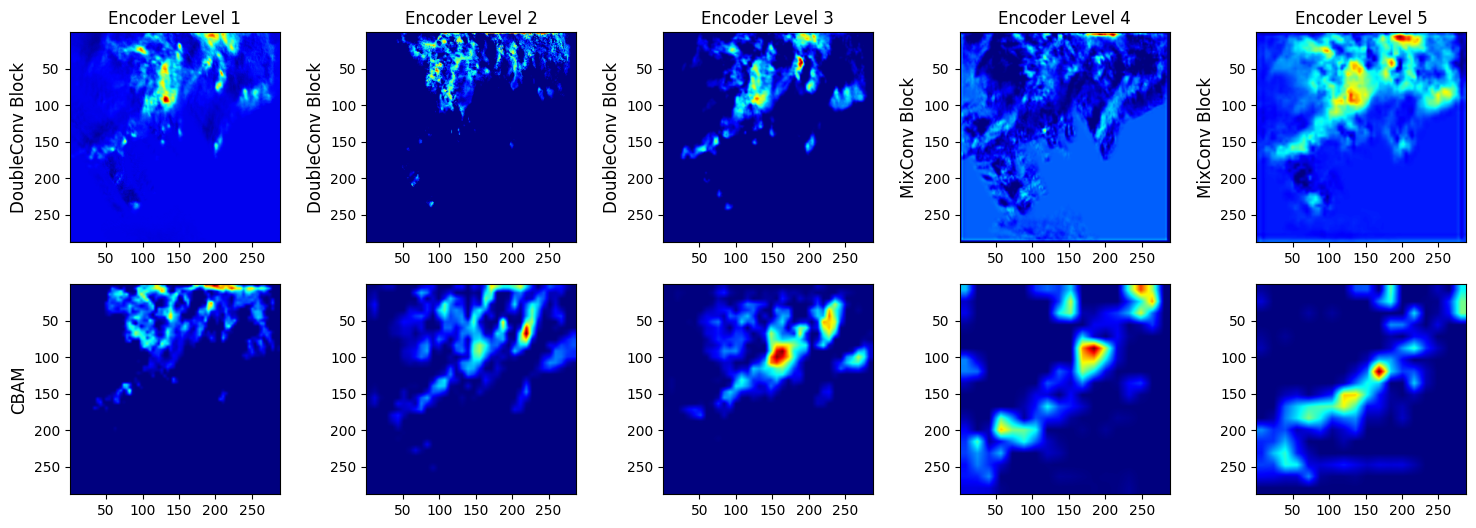

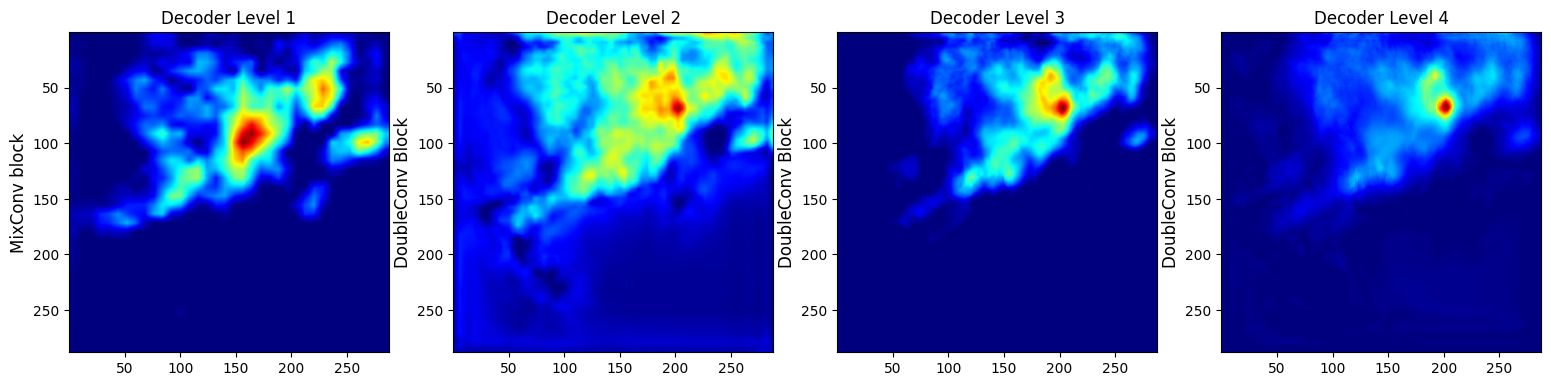

In [15]:
from torch.utils.data import DataLoader
import numpy as np
import os
import torch
from utils import dataset_precip
from tqdm import tqdm
from models import SmaAT_UNet_VQ_lightning
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam import GradCAM
from argparse import Namespace

warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')


class SemanticSegmentationTarget:
    def __init__(self, category, mask, device):
        self.category = category
        self.mask = torch.from_numpy(mask)
        if device == 'cuda':
            self.mask = self.mask.cuda()

    def __call__(self, model_output):
        return (model_output[self.category, :, :] * self.mask).sum()


def load_model(model_cls, model_folder, device, model_type="partialmixconv"):
    ckpts = [fn for fn in os.listdir(model_folder) if fn.endswith(".ckpt")]
    if not ckpts:
        raise FileNotFoundError(f"No .ckpt found in {model_folder!r}")
    ckpt_file = sorted(ckpts)[-1]
    ckpt_path = os.path.join(model_folder, ckpt_file)
    checkpoint = torch.load(ckpt_path, map_location=device)
    hparams = checkpoint.get("hyper_parameters", {})
    if "model_type" not in hparams:
        hparams["model_type"] = model_type
    model = model_cls(Namespace(**hparams))
    state_dict = checkpoint.get("state_dict", checkpoint)
    new_state_dict = {
        key[len("model."):] if key.startswith("model.") else key: val
        for key, val in state_dict.items()
    }
    model.load_state_dict(new_state_dict)
    model.eval()
    model.to(torch.device(device))
    return model


def get_segmentation_data(in_channels):
    ds = dataset_precip.precipitation_maps_oversampled_h5(
        in_file=data_file,
        num_input_images=in_channels,
        num_output_images=6,
        train=False
    )
    return DataLoader(ds, batch_size=1, shuffle=False,
                      num_workers=0, pin_memory=True)


def run_cam(model, target_layers, device, in_channels):
    test_dl = get_segmentation_data(in_channels)
    x_ticks = [50, 100, 150, 200, 250]

    for x, _ in tqdm(test_dl, leave=False):
        x = x.to(torch.device(device))
        logits, _, _ = model(x)

        # build mask for Grad-CAM
        mask = np.digitize(
            (logits[0, 0] * 47.83 * 12).detach().cpu().numpy(),
            np.array([0.5]), right=True
        ).astype(np.float32)

        print("Total mask pixels:", mask.sum())

        # base image
        img = torch.stack([x[0, 0]] * 3, dim=2).cpu().numpy()
        targets = [SemanticSegmentationTarget(0, mask, device)]

        # compute CAMs
        cams_all = []
        for layer in target_layers:
            with GradCAM(model=model, target_layers=layer) as cam:
                gcam = cam(input_tensor=x, targets=targets)[0]
                cams_all.append(show_cam_on_image(img, gcam, use_rgb=True))

        # select the indices we plot
        display_idx = [1,2,4,5,7,8,9,10,11,12, 13,14,15,16]
        cams = [cams_all[i] for i in display_idx]
        enc_imgs, dec_imgs = cams[:10], cams[10:]

        # reset to default subplot spacing
        mpl.rcParams.update(mpl.rcParamsDefault)

        # ─── ENCODER: 2 rows × 5 columns ────────────────────────────────────
        fig, axes = plt.subplots(
            2, 5,
            figsize=(18.5, 6)
        )
        idx = 0
        for row in range(2):
            for col in range(5):
                ax = axes[row, col]
                ax.imshow(enc_imgs[idx], extent=[0, 288, 288, 0])
                if row == 0:
                    # column titles
                    ax.set_title(f"Encoder Level {col+1}", fontsize=12)
                    # block label per column
                    if col < 3:
                        ax.set_ylabel("DoubleConv Block", fontsize=12)
                    else:
                        ax.set_ylabel("MixConv Block", fontsize=12)
                else:
                    # CBAM row: label only first column
                    if col == 0:
                        ax.set_ylabel("CBAM", fontsize=12)
                ax.set_xticks(x_ticks)
                ax.set_yticks(x_ticks)
                idx += 1

        # ─── DECODER: 1 row × 4 columns ────────────────────────────────────
        decoder_blocks = [
            'MixConv block',
            'DoubleConv Block',
            'DoubleConv Block',
            'DoubleConv Block'
        ]
        fig2, axes2 = plt.subplots(1, 4, figsize=(19, 5))
        for col in range(4):
            ax = axes2[col]
            ax.imshow(dec_imgs[col], extent=[0, 288, 288, 0])
            ax.set_title(f"Decoder Level {col+1}", fontsize=12)
            # rotate and place block label on y-axis
            ax.set_ylabel(decoder_blocks[col],
                          fontsize=12,
                          rotation=90,
                          labelpad=10,
                          va='center')
            ax.set_xticks(x_ticks)
            ax.set_yticks(x_ticks)

        plt.show()
        # break


if __name__ == '__main__':
    # hyperparameters (only dataset path used below)
    hparams = {
        'n_channels': 12,
        'dataset_folder': "data/precipitation/"
                          "train_test_2016-2019_input-length_12_"
                          "img-ahead_6_rain-threshold_50.h5"
    }

    model_folder = "checkpoints/comparison"
    data_file = os.path.join(hparams['dataset_folder'])
    device = 'cpu'

    model = load_model(SmaAT_UNet_VQ_lightning.SmaAT_UNet_VQ,
                       model_folder, device)

    target_layers = [
        [model.inc.double_conv[1]],
        [model.inc.double_conv[3]],
        [model.cbam1],
        [model.down1.maxpool_conv[1].double_conv[0]],
        [model.down1.maxpool_conv[1].double_conv[3]],
        [model.cbam2],
        [model.down2.maxpool_conv[1].double_conv[0]],
        [model.down2.maxpool_conv[1].double_conv[3]],
        [model.cbam3],
        [model.down3.maxpool_conv[1].mix1],
        [model.cbam4],
        [model.down4.maxpool_conv[1].mix1],
        [model.cbam5],
        [model.up1.conv.mix1],
        [model.up2.conv.double_conv[5]],
        [model.up3.conv.double_conv[5]],
        [model.up4.conv.double_conv[5]],
    ]

    run_cam(model, target_layers, device, hparams['n_channels'])
